In [82]:
# R1-A1-S1 Redes Neuronales básicas
# Autor: Bryan Felipe Roa Alvarado
# ---------------------------------------------------------------
# Descripción:
#   Implementación desde cero de tres modelos de clasificación
#   binaria sobre una misma matriz de entrada (3 muestras, 4
#   características):
#     1. Perceptrón simple
#     2. Red neuronal de una capa
#     3. Red neuronal multicapa (vainilla)
#
#   Se incluye además el ejemplo de la compuerta XOR para
#   evidenciar la ventaja de la red multicapa frente a los
#   modelos de una sola capa.

In [83]:
import numpy as np

# 1. Perceptron
class Perceptron:
    def __init__(self, nEntradas, tasaAprendizaje=0.1, epocas=1000):
        """
        nEntradas: número de características de entrada
        tasaAprendizaje: controla qué tan grandes son los ajustes de los pesos en cada error.
        epocas: número de pasadas sobre el dataset
        """
        # Inicializamos pesos y sesgo en cero (o valores pequeños aleatorios)
        self.pesos = np.zeros(nEntradas)
        self.sesgo = 0.0
        self.tasaAprendizaje = tasaAprendizaje
        self.epocas = epocas

    def predecir(self, X):
        """Calcula la salida para una o varias muestras."""
        suma = np.dot(X, self.pesos) + self.sesgo
        return np.where(suma >= 0, 1, 0)

    def entrenar(self, X, y):
        """Ajusta pesos y sesgo usando la regla de aprendizaje."""
        for _ in range(self.epocas):
            errores = 0
            for xi, yi in zip(X, y):
                salida = self.predecir(xi)
                error = yi - salida
                if error != 0:
                    # Actualización del perceptrón
                    self.pesos += self.tasaAprendizaje * error * xi
                    self.sesgo += self.tasaAprendizaje * error
                    errores += 1
            # Si no hubo errores, ya convergió
            if errores == 0:
                break

# 2. Red neuronal de 1 capa
class RedNeuronalUnaCapa:
    def __init__(self, nEntradas, tasaAprendizaje=0.1, epocas=1000):
        # Pesos y sesgo inicializados con valores pequeños aleatorios
        # (no en cero, porque con sigmoide puede quedar atascada)
        np.random.seed(42)
        self.pesos = np.random.randn(nEntradas) * 0.01
        self.sesgo = 0.0
        self.tasaAprendizaje = tasaAprendizaje
        self.epocas = epocas
        self.historial_error = []   # para ver cómo baja el error

    def sigmoide(self, z):
        """Función de activación: devuelve valores entre 0 y 1."""
        return 1 / (1 + np.exp(-z))

    def sigmoide_derivada(self, a):
        """Derivada de la sigmoide, expresada en función de su salida."""
        return a * (1 - a)

    def predecir(self, X):
        """Devuelve la probabilidad (valor continuo entre 0 y 1)."""
        z = np.dot(X, self.pesos) + self.sesgo
        return self.sigmoide(z)

    def predecir_clase(self, X):
        """Convierte la probabilidad en clase 0 o 1 (umbral 0.5)."""
        return np.where(self.predecir(X) >= 0.5, 1, 0)

    def entrenar(self, X, y):
        for epoca in range(self.epocas):
            # --- Propagación hacia adelante ---
            z = np.dot(X, self.pesos) + self.sesgo
            salida = self.sigmoide(z)          # a = σ(z)

            # --- Cálculo del error (error cuadrático medio) ---
            error = y - salida
            self.historial_error.append(np.mean(error ** 2))

            # --- Retropropagación (gradiente) ---
            # delta = error * derivada de la sigmoide
            delta = error * self.sigmoide_derivada(salida)

            # --- Actualización de pesos y sesgo ---
            self.pesos += self.tasaAprendizaje * np.dot(X.T, delta)
            self.sesgo += self.tasaAprendizaje * np.sum(delta)

        return self

# 3. Red neuronal de multicapa
class RedNeuronalMulticapa:
    def __init__(self, nEntradas, nOcultas, nSalidas,
                 tasaAprendizaje=0.5, epocas=5000):
        np.random.seed(42)
        # Pesos capa entrada → oculta
        self.W1 = np.random.randn(nEntradas, nOcultas) * 0.5
        self.b1 = np.zeros((1, nOcultas))
        # Pesos capa oculta → salida
        self.W2 = np.random.randn(nOcultas, nSalidas) * 0.5
        self.b2 = np.zeros((1, nSalidas))

        self.tasaAprendizaje = tasaAprendizaje
        self.epocas = epocas
        self.historial_error = []

    def sigmoide(self, z):
        """Función de activación: comprime cualquier valor real al rango (0, 1)."""
        return 1 / (1 + np.exp(-z))

    def sigmoide_derivada(self, a):
        """Derivada de la sigmoide expresada en función de su salida 'a'."""
        return a * (1 - a)

    def forward(self, X):
        """Propagación hacia adelante por todas las capas."""
        # Capa entrada → oculta
        z1 = np.dot(X, self.W1) + self.b1
        a1 = self.sigmoide(z1)

        # Capa oculta → salida
        z2 = np.dot(a1, self.W2) + self.b2
        a2 = self.sigmoide(z2)

        return z1, a1, z2, a2

    def predecir(self, X):
        """Devuelve la probabilidad continua (valor entre 0 y 1)."""
        _, _, _, a2 = self.forward(X)
        return a2

    def predecir_clase(self, X):
        """Convierte la probabilidad en clase binaria usando umbral 0.5."""
        return np.where(self.predecir(X) >= 0.5, 1, 0)

    def entrenar(self, X, y):
        y = y.reshape(-1, 1)   # asegurar forma (n, 1)

        for _ in range(self.epocas):
            # ---------- FORWARD ----------
            z1, a1, z2, a2 = self.forward(X)

            # ---------- ERROR ----------
            # Error cuadrático medio: métrica estándar para evaluar la convergencia.
            error = y - a2
            self.historial_error.append(np.mean(error ** 2))

            # ---------- BACKPROP ----------
            # Delta de la capa de salida
            delta2 = error * self.sigmoide_derivada(a2)

            # Delta de la capa oculta (propagando el error hacia atrás)
            delta1 = np.dot(delta2, self.W2.T) * self.sigmoide_derivada(a1)

            # ---------- UPDATE ----------
            self.W2 += self.tasaAprendizaje * np.dot(a1.T, delta2)
            self.b2 += self.tasaAprendizaje * np.sum(delta2, axis=0, keepdims=True)
            self.W1 += self.tasaAprendizaje * np.dot(X.T, delta1)
            self.b1 += self.tasaAprendizaje * np.sum(delta1, axis=0, keepdims=True)

        return self

In [84]:
import numpy as np

# Datos de entrada: 3 muestras, 4 características cada una
X = np.array([
    [0.80, 0.60, 0.70, 0.50],
    [0.30, 0.40, 0.20, 0.10],
    [0.90, 0.80, 0.90, 0.70]
])

# Etiquetas esperadas (una por muestra)
y = np.array([1, 0, 1])

# Crear y entrenar el perceptrón (4 entradas)
perceptron = Perceptron(nEntradas=4, tasaAprendizaje=0.1, epocas=1000)
perceptron.entrenar(X, y)

# Probar
print("Pesos:", perceptron.pesos)
print("Sesgo:", perceptron.sesgo)
print("\nPredicciones:")
for xi, yi in zip(X, y):
    pred = perceptron.predecir(xi)
    print(f"Entrada: {xi} | Esperado: {yi} | Predicho: {pred}")

Pesos: [0.08 0.02 0.1  0.09]
Sesgo: -0.1

Predicciones:
Entrada: [0.8 0.6 0.7 0.5] | Esperado: 1 | Predicho: 1
Entrada: [0.3 0.4 0.2 0.1] | Esperado: 0 | Predicho: 0
Entrada: [0.9 0.8 0.9 0.7] | Esperado: 1 | Predicho: 1


Entrada: [0.8 0.6 0.7 0.5] | Esperado: 1 | Prob: 0.9527 | Clase: 1
Entrada: [0.3 0.4 0.2 0.1] | Esperado: 0 | Prob: 0.0586 | Clase: 0
Entrada: [0.9 0.8 0.9 0.7] | Esperado: 1 | Prob: 0.9941 | Clase: 1




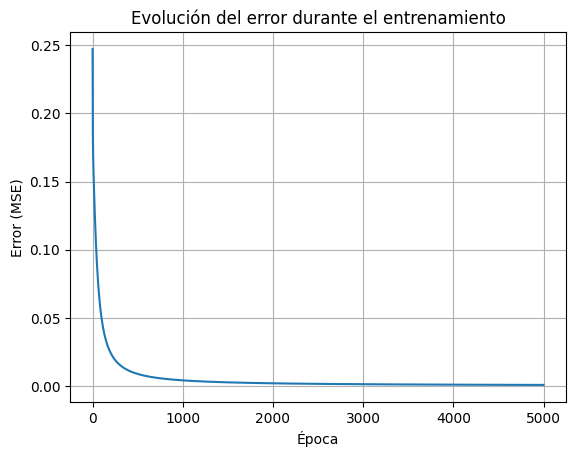

In [85]:
import numpy as np

# Se realiza el mismo ejemplo de la matriz 3x4 pero con la red neuronal de 1 capa
X = np.array([
    [0.80, 0.60, 0.70, 0.50],
    [0.30, 0.40, 0.20, 0.10],
    [0.90, 0.80, 0.90, 0.70]
])
y = np.array([1, 0, 1], dtype=float)

# Crear y entrenar la red
red = RedNeuronalUnaCapa(nEntradas=X.shape[1], tasaAprendizaje=0.5, epocas=2000)
red.entrenar(X, y)

# Probar
for xi, yi in zip(X, y):
    prob = red.predecir(xi)
    clase = red.predecir_clase(xi)
    print(f"Entrada: {xi} | Esperado: {int(yi)} | Prob: {prob:.4f} | Clase: {clase}")


# La gráfica muestra la evolución del error (MSE) a lo largo de las épocas,
# evidenciando que la red converge correctamente al disminuir el error.
import matplotlib.pyplot as plt

red = RedNeuronalUnaCapa(4, tasaAprendizaje=0.5, epocas=5000)
red.entrenar(X, y)

print("\n")
plt.plot(red.historial_error)
plt.xlabel("Época")
plt.ylabel("Error (MSE)")
plt.title("Evolución del error durante el entrenamiento")
plt.grid(True)
plt.show()

Pesos W1 (entrada→oculta):
 [[ 1.69480358 -1.73995174 -1.35677969]
 [ 0.72539882 -0.38840383 -0.36169738]
 [ 2.57581163 -1.58537193 -2.21990347]
 [ 1.88879808 -1.966026   -1.98440066]]
Sesgo b1:
 [[-2.6325197   1.98689143  2.07929181]]
Pesos W2 (oculta→salida):
 [[ 5.41876501]
 [-4.22879183]
 [-4.45513525]]
Sesgo b2:
 [[0.64175211]]

Predicciones:
Entrada: [0.8 0.6 0.7 0.5] | Esperado: 1 | Prob: 0.9833 | Clase: 1
Entrada: [0.3 0.4 0.2 0.1] | Esperado: 0 | Prob: 0.0163 | Clase: 0
Entrada: [0.9 0.8 0.9 0.7] | Esperado: 1 | Prob: 0.9951 | Clase: 1




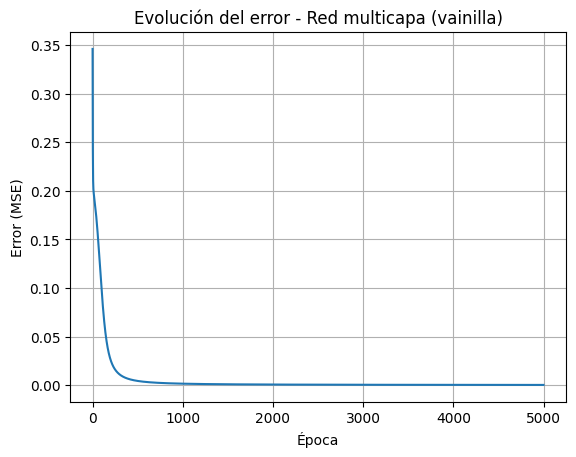



XOR resuelto:
[0 0] → esperado 0 | prob 0.0183 | clase 0
[0 1] → esperado 1 | prob 0.9836 | clase 1
[1 0] → esperado 1 | prob 0.9836 | clase 1
[1 1] → esperado 0 | prob 0.0171 | clase 0


In [86]:
import numpy as np
import matplotlib.pyplot as plt

# Se realiza el mismo ejemplo de la matriz 3x4 pero con la red neuronal multicapa
X = np.array([
    [0.80, 0.60, 0.70, 0.50],
    [0.30, 0.40, 0.20, 0.10],
    [0.90, 0.80, 0.90, 0.70]
])
y = np.array([1, 0, 1], dtype=float)

# Crear la red multicapa
red = RedNeuronalMulticapa(
    nEntradas = X.shape[1],   # 4
    nOcultas  = 3,            # capa oculta con 3 neuronas
    nSalidas  = 1,            # clasificación binaria
    tasaAprendizaje = 0.5,
    epocas = 5000
)

# Entrenar
red.entrenar(X, y)

# Resultados
print("Pesos W1 (entrada→oculta):\n", red.W1)
print("Sesgo b1:\n", red.b1)
print("Pesos W2 (oculta→salida):\n", red.W2)
print("Sesgo b2:\n", red.b2)

print("\nPredicciones:")
for xi, yi in zip(X, y):
    prob = red.predecir(xi.reshape(1, -1))[0, 0]
    clase = red.predecir_clase(xi.reshape(1, -1))[0, 0]
    print(f"Entrada: {xi} | Esperado: {int(yi)} | Prob: {prob:.4f} | Clase: {clase}")

# La gráfica muestra la evolución del error (MSE) a lo largo de las épocas
# durante el entrenamiento de la red neuronal multicapa. Se observa una
# disminución progresiva del error, lo que evidencia que el algoritmo de
# retropropagación (backpropagation) ajusta correctamente los pesos de
# ambas capas y la red converge.
print("\n")
plt.plot(red.historial_error)
plt.xlabel("Época")
plt.ylabel("Error (MSE)")
plt.title("Evolución del error - Red multicapa (vainilla)")
plt.grid(True)
plt.show()


# Ejemplo XOR: caso no linealmente separable que evidencia la ventaja
# de la red neuronal multicapa frente al perceptrón y la red de una capa.
X = np.array([
    [0, 0],
    [0, 1],
    [1, 0],
    [1, 1]
])
y = np.array([0, 1, 1, 0], dtype=float)

red = RedNeuronalMulticapa(nEntradas=2, nOcultas=3, nSalidas=1,
                            tasaAprendizaje=0.5, epocas=10000)
red.entrenar(X, y)

print("\n")
print("XOR resuelto:")
for xi, yi in zip(X, y):
    prob = red.predecir(xi.reshape(1, -1))[0, 0]
    clase = red.predecir_clase(xi.reshape(1, -1))[0, 0]
    print(f"{xi} → esperado {int(yi)} | prob {prob:.4f} | clase {clase}")

## Explicación básica del funcionamiento del código

El código implementa tres modelos de clasificación binaria, cada uno
como una clase de Python. La estructura de los tres es similar:

**1. Inicialización (`__init__`)**
Se crean los pesos y el sesgo con valores iniciales (ceros en el
perceptrón, valores pequeños aleatorios en las redes). También se
guardan los hiperparámetros: tasa de aprendizaje y número de épocas.

**2. Propagación hacia adelante (`predecir` / `forward`)**
Se calcula la suma ponderada de las entradas: `z = X·w + b`.
Luego se aplica una función de activación:
- **Perceptrón:** función escalón (devuelve 0 o 1).
- **Redes neuronales:** función sigmoide (devuelve un valor entre 0 y 1).

**3. Entrenamiento (`entrenar`)**
Se repite el siguiente ciclo durante todas las épocas:
- Se calcula la salida del modelo (forward).
- Se mide el error respecto a las etiquetas reales.
- Se ajustan los pesos y el sesgo según ese error.

**Diferencias clave entre los modelos:**

| Modelo | Activación | Ajuste de pesos |
|--------|-----------|-----------------|
| Perceptrón | Escalón | Regla del perceptrón (por muestra) |
| Red 1 capa | Sigmoide | Descenso del gradiente |
| Red multicapa | Sigmoide | Backpropagation (varias capas) |

**En la red multicapa**, el error se propaga hacia atrás desde la
capa de salida hasta la capa oculta (retropropagación), lo que permite
ajustar los pesos de todas las capas. Esto le permite resolver
problemas no lineales como XOR.